In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("/content/Mall_Customers.csv")

In [3]:
print(data.head())
print(data.info())
print(data.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

In [4]:
print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
def clean_text(text):
    # Ensure text is a string before processing
    if isinstance(text, float):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
data['clean_text'] = data['Gender'].fillna('').apply(clean_text)

In [9]:
X = data['clean_text']
# Dependent Variable (y) – if available
y = data['Spending Score (1-100)']

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (
    X_tfidf, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
valid_indices = ~y_test.isnull()
y_test_filtered = y_test[valid_indices]
y_pred_filtered = y_pred[valid_indices.values]

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test_filtered, y_pred_filtered))
print("R-squared (R2 Score):", r2_score(y_test_filtered, y_pred_filtered))

Mean Absolute Error (MAE): 18.6939868485662
R-squared (R2 Score): -0.09667389669848436


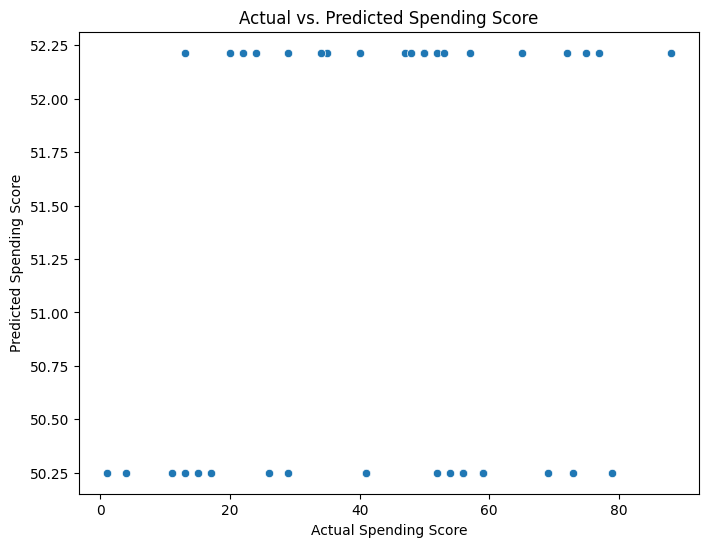

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_filtered, y=y_pred_filtered)
plt.xlabel("Actual Spending Score")
plt.ylabel("Predicted Spending Score")
plt.title("Actual vs. Predicted Spending Score")
plt.show()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
# Combine all text into one string
text_data = " ".join(data['clean_text'].astype(str))
# Add custom stopwords if needed
custom_stopwords.update(['mall', 'customer'])
# You can add specific words here, for example:
# custom_stopwords.update(['mall', 'customer'])

In [27]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=200,
    colormap='viridis' # Corrected 'viidis' to 'viridis'
).generate(text_data)

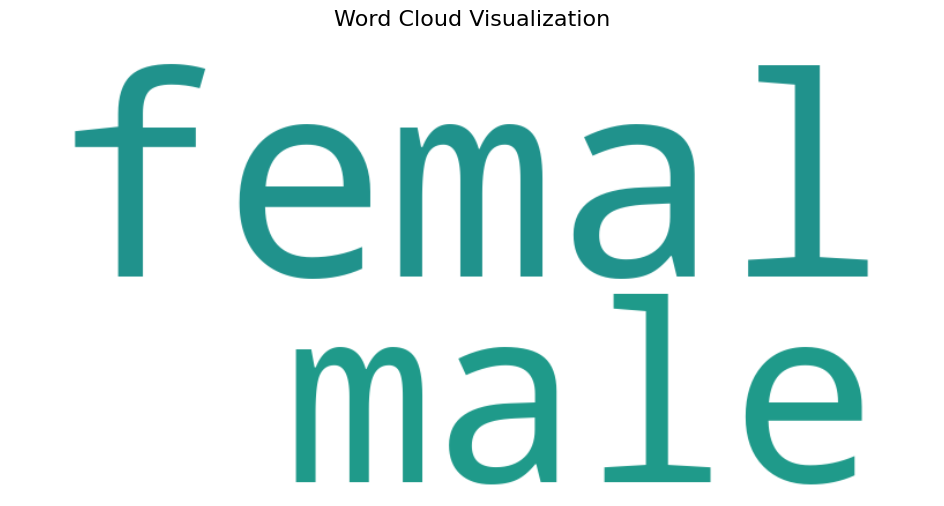

In [28]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Visualization", fontsize=16)
plt.show()

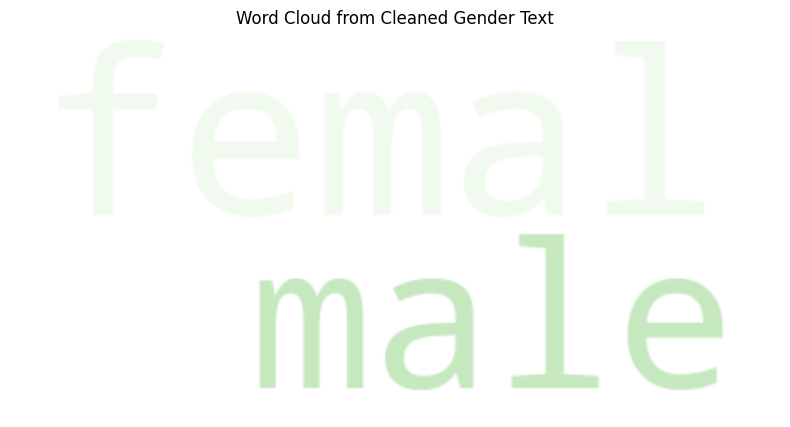

In [30]:
all_cleaned_text = " ".join(data['clean_text'].astype(str))

wordcloud_all = WordCloud(
    background_color='white',
    colormap='Greens'
).generate(all_cleaned_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud from Cleaned Gender Text")
plt.show()